TWITTER SENTIMENT ANALYSIS USING NATURAL LANGUAGE PROCESSING (NLP)

This project focuses on analyzing sentiment from Twitter data using Natural Language Processing techniques.

The main objective is to classify tweets into three sentiment categories:

- Positive 😊
- Negative 😡
- Neutral  😐

By analyzing tweet text, the project helps understand public opinion, user reactions, and sentiment trends on social media platforms.

Additionally, engagement metrics such as likes and retweets are explored to gain deeper insights into how sentiment influences audience interaction.

This analysis can help organizations, researchers, and marketers understand customer feedback, track public perception, and make data-driven decisions.

VIEW FILES IN THE WORKING DIRECTORY

The os library is used to interact with the operating system.  
Here, we use the listdir() function to display all files and folders present in the current working directory.  

This helps us verify that the dataset file is available before loading it for analysis.

In [1]:
import os
os.listdir()

['CodeAlpha_Task4_Sentiment_Analysis.ipynb',
 'Screenshorts',
 'twitter_dataset.csv',
 'twitter_mask.png']

IMPORT REQUIRED LIBRARIES

In this section, we import the essential Python libraries used for Twitter Sentiment Analysis. These libraries help with data handling, visualization, and Natural Language Processing (NLP).

Pandas – For loading and analyzing the dataset

NumPy – For numerical operations

Matplotlib – For creating data visualizations

Seaborn – For attractive statistical plots

TextBlob – For performing sentiment analysis on tweet text

WordCloud – For visualizing the most frequent words in tweets

PIL (Image) – For loading and processing images used as masks in WordCloud

These libraries help transform raw Twitter data into meaningful insights.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud
from PIL import Image

LOAD AND PREVIEW DATASET

In this step, we load the Twitter dataset containing 10,000 tweets to begin the sentiment analysis process. 

The output above shows the first few rows of the Twitter dataset.
This helps confirm that the data is loaded correctly and gives a quick look at the dataset before further analysis.


In [3]:
df = pd.read_csv("twitter_dataset.csv", nrows=10000)

df.head()

,Tweet_ID,Username,Text,Retweets,Likes,Timestamp,City,Country
0,1,julie81,Party least receive say or single. Prevent pre...,2,25,1/30/2023 11:00,Stockholm,Sweden
1,2,richardhester,Hotel still Congress may member staff. Media d...,35,29,1/2/2023 22:45,Los Angeles,United States
2,3,williamsjoseph,Receive difference their. Responsibility build...,51,25,1/18/2023 11:25,Rome,Italy
3,4,danielsmary,Laugh explain situation career occur serious. ...,37,18,4/10/2023 22:06,Kuala Lumpur,Malaysia
4,5,carlwarren,Paper but then field audience. Read pick sudde...,27,80,1/24/2023 7:12,Guadalajara,Mexico


DATASET OVERVIEW

This step provides a quick summary of the dataset.  
We check the number of rows and columns, explore the column names, and review the data types of each column.

Understanding the dataset structure helps ensure that the data is loaded correctly and prepares it for data cleaning, analysis, and visualization.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Tweet_ID   10000 non-null  int64
 1   Username   10000 non-null  str  
 2   Text       10000 non-null  str  
 3   Retweets   10000 non-null  int64
 4   Likes      10000 non-null  int64
 5   Timestamp  10000 non-null  str  
 6   City       10000 non-null  str  
 7   Country    10000 non-null  str  
dtypes: int64(3), str(5)
memory usage: 625.1 KB


In [5]:
df.describe()

,Tweet_ID,Retweets,Likes
count,10000.00000,10000.000000,10000.000000
mean,5000.50000,49.721200,49.929300
std,2886.89568,28.948856,28.877193
min,1.00000,0.000000,0.000000
25%,2500.75000,25.000000,25.000000
50%,5000.50000,49.000000,50.000000
75%,7500.25000,75.000000,75.000000
max,10000.00000,100.000000,100.000000


CHECK MISSING VALUES

Missing values can negatively impact data analysis and lead to inaccurate results. In this step, we examine the dataset to identify any missing or null values to ensure the data quality and reliability of our analysis.

In [5]:
df.isnull().sum()

Tweet_ID     0
Username     0
Text         0
Retweets     0
Likes        0
Timestamp    0
City         0
Country      0
dtype: int64

DATA CLEANING

Tweets often contain links, special characters, and unnecessary symbols.  
In this step, we clean and preprocess the text to improve data quality and prepare it for accurate sentiment analysis.

In [6]:
df["Text"] = df["Text"].str.lower()

df.columns = df.columns.str.strip()

df["Likes"] = pd.to_numeric(df["Likes"], errors="coerce")

df["Retweets"] = pd.to_numeric(df["Retweets"], errors="coerce")

df.dropna(inplace=True)

df[["Text","Likes","Retweets"]].head()




,Text,Likes,Retweets
0,party least receive say or single. prevent pre...,25,2
1,hotel still congress may member staff. media d...,29,35
2,receive difference their. responsibility build...,25,51
3,laugh explain situation career occur serious. ...,18,37
4,paper but then field audience. read pick sudde...,80,27


SENTIMENT ANALYSIS

In this step, Natural Language Processing (NLP) techniques are applied to analyze the sentiment of tweets.  
Each tweet is classified into one of the following categories:

• Positive 😊 
• Negative 😡  
• Neutral  😐


In [7]:
def get_sentiment(Text):
    analysis = TextBlob(Text)
    if analysis.sentiment.polarity > 0:
        return "Positive"
    elif analysis.sentiment.polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Text"].apply(get_sentiment)

# Only for DISPLAY — all columns still exist in df
df[["Text", "Sentiment"]].head()

,Text,Sentiment
0,party least receive say or single. prevent pre...,Positive
1,hotel still congress may member staff. media d...,Positive
2,receive difference their. responsibility build...,Negative
3,laugh explain situation career occur serious. ...,Positive
4,paper but then field audience. read pick sudde...,Neutral


SENTIMENT DISTRIBUTION

This section presents the distribution of tweets across different sentiment categories, showing how many tweets are classified as Positive, Negative, and Neutral.

In [8]:
sentiment_counts = df["Sentiment"].value_counts()

sentiment_counts

Sentiment
Positive    7732
Negative    2066
Neutral      202
Name: count, dtype: int64

SENTIMENT VISUALIZATION

Visualizing sentiment distribution helps to clearly understand overall public opinion and identify patterns in positive, negative, and neutral sentiments.

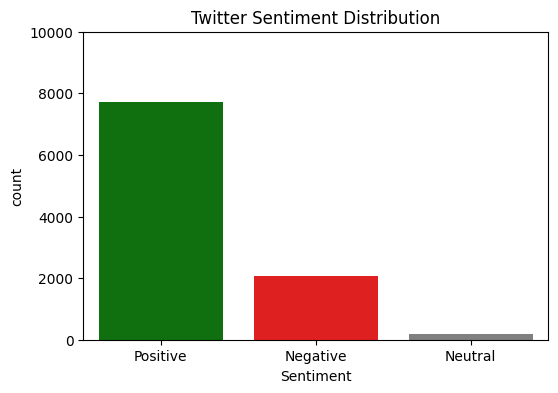

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sentiment", data=df, hue="Sentiment",
              palette=["green","red","gray"], legend=False)

plt.title("Twitter Sentiment Distribution")

plt.ylim(0, 10000)

plt.show()

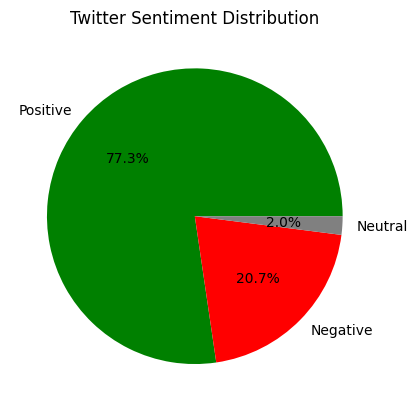

In [10]:
sentiment_counts = df["Sentiment"].value_counts()

colors = ["green","red","gray"]

sentiment_counts.plot(kind="pie", autopct="%1.1f%%", colors=colors)

plt.title("Twitter Sentiment Distribution")
plt.ylabel("")
plt.show()

WORD CLOUD ANALYSIS

A word cloud visually displays the most frequently used words in tweets, helping to quickly identify common topics and key terms in the data.

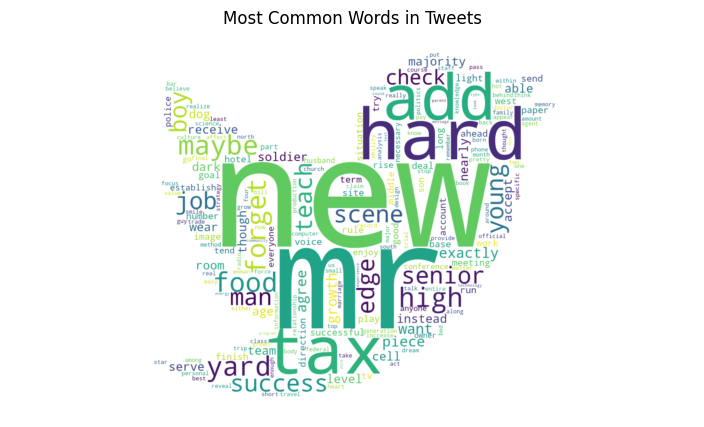

In [11]:
text = " ".join(df["Text"])

# load twitter logo mask image
mask = np.array(Image.open("twitter_mask.png"))

# generate wordcloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    mask=mask,
    colormap="viridis"
).generate(text)

# display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Tweets")
plt.show()

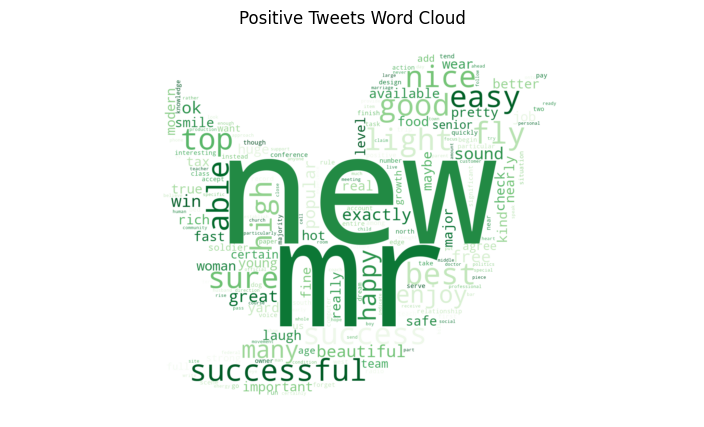

In [12]:
positive_text = " ".join(df[df["Sentiment"] == "Positive"]["Text"].dropna())

# Load Twitter logo mask
mask = np.array(Image.open("twitter_mask.png"))

# Generate WordCloud
wordcloud = WordCloud(
    background_color="white",
    mask=mask,
    colormap="Greens"
).generate(positive_text)

# Display WordCloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Tweets Word Cloud")
plt.show()

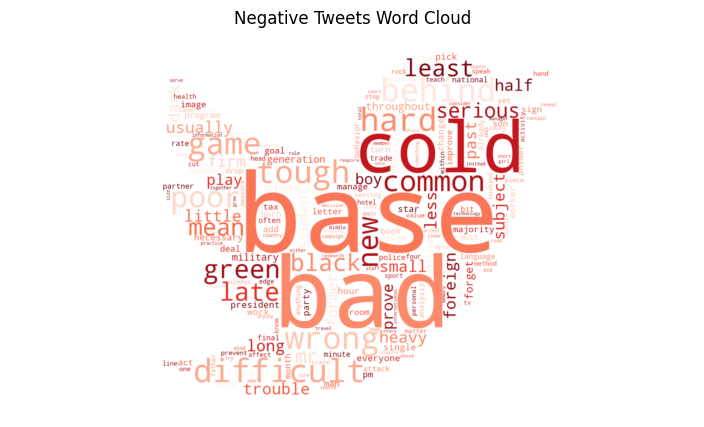

In [13]:
# Create text from negative tweets
negative_text = " ".join(df[df["Sentiment"] == "Negative"]["Text"].dropna())

# Load Twitter logo mask
mask = np.array(Image.open("twitter_mask.png"))

# Generate WordCloud
wordcloud = WordCloud(
    background_color="white",
    mask=mask,
    colormap="Reds"
).generate(negative_text)

# Display WordCloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Tweets Word Cloud")
plt.show()

ENGAGEMENT ANALYSIS

This section explores how tweet sentiment influences user engagement by examining interactions such as likes and retweets.

In [14]:
df.groupby("Sentiment")[["Likes","Retweets"]].mean()


,Likes,Retweets
Sentiment,,
Negative,49.694095,49.678606
Neutral,54.178218,51.277228
Positive,49.881143,49.691930


SENTIMENT VS LIKES ANALYSIS

This visualization illustrates how different tweet sentiments relate to user engagement by analyzing the number of likes each sentiment category receives.

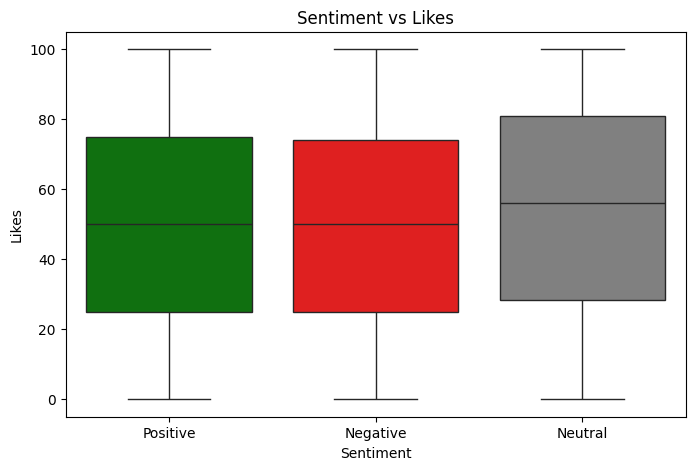

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Sentiment", y="Likes", hue="Sentiment",
            data=df, palette=["green","red","gray"],
            legend=False)

plt.title("Sentiment vs Likes")

plt.show()

SENTIMENT VS RETWEETS ANALYSIS

This visualization shows how different sentiments influence tweet sharing, highlighting the relationship between sentiment categories and retweet activity.

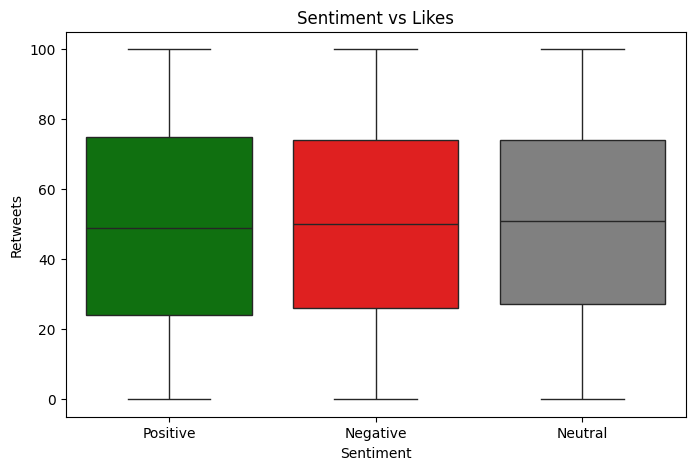

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Sentiment", y="Retweets", hue="Sentiment",
            data=df, palette=["green","red","gray"],
            legend=False)

plt.title("Sentiment vs Likes")

plt.show()

TOP COUNTRIES BY TWEET ACTIVITY

This visualization shows the countries with the highest tweet activity in the dataset, helping to identify regions with the most user engagement.

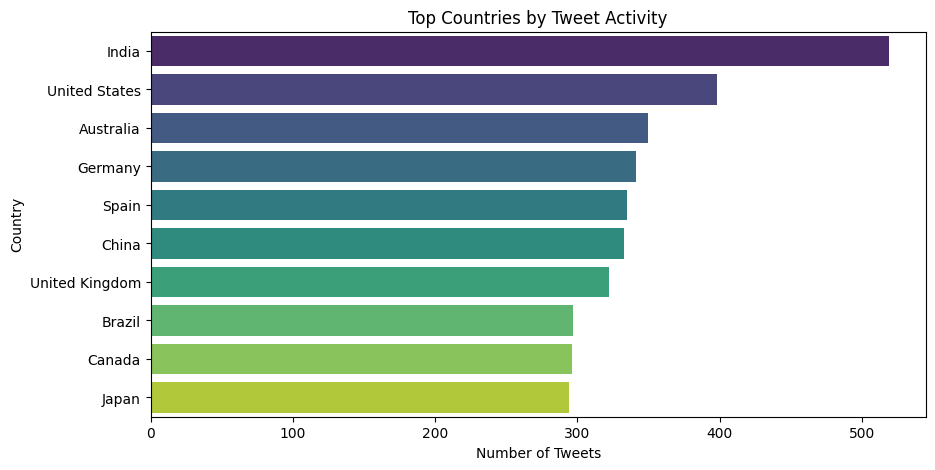

In [17]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette=sns.color_palette("viridis",10),
    legend=False
)

plt.title("Top Countries by Tweet Activity")
plt.xlabel("Number of Tweets")

plt.show()

SENTIMENT DISTRIBUTION BY COUNTRY

This visualization illustrates how tweet sentiments are distributed across different countries, helping to understand variations in public opinion by location.

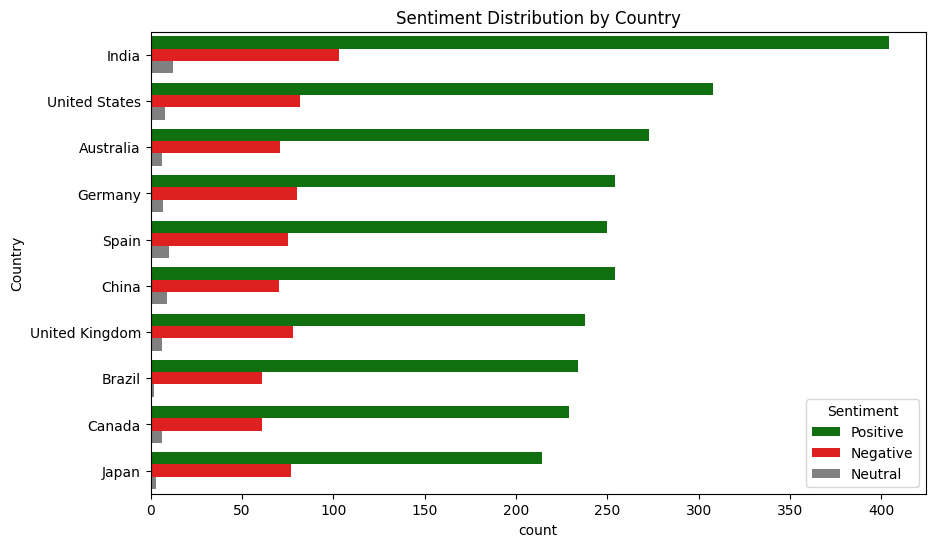

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="Country",
    hue="Sentiment",
    data=df,
    order=df["Country"].value_counts().index[:10],
    palette={"Positive":"green","Negative":"red","Neutral":"gray"}
)

plt.title("Sentiment Distribution by Country")

plt.show()

KEY INSIGHTS

• Positive tweets reflect supportive and favorable opinions.  
• Negative tweets highlight criticism or dissatisfaction.  
• Neutral tweets present general information or unbiased statements.  

These insights help in understanding and tracking public opinion trends on social media.

CONCLUSION

This project demonstrates how Natural Language Processing (NLP) can be used to analyze public sentiment from Twitter data. By classifying tweets into positive, negative, and neutral categories, the analysis provides clear insights into public opinion and engagement patterns on social media.